In [19]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Step 2: Load and preprocess dataset
df = pd.read_csv("labelled_merged_dataset.csv")

title_counts = df['Title'].value_counts()
df['IsChain'] = df['Title'].apply(lambda x: 1 if title_counts[x] > 1 else 0)

def parse_categories(x):
    try:
        return len(ast.literal_eval(x)) if pd.notnull(x) else 0
    except:
        return 0
df['tag_count'] = df['Categories'].apply(parse_categories)
df['RatingBinary'] = df['Rating'].map({'Good': 1, 'Bad': 0})

df.head()

,Title,Category,Rating,Address,Categories,ZCTA,NAME,Median_Income,Population,Males_20yrs_age,Males_30yrs_age,Males_60yrs_age,Females_20yrs_age,Females_30yrs_age,Females_60yrs_age,Asian,American,Hispanic_or_Latino,IsChain,tag_count,RatingBinary
0,Dairy Queen Grill & Chill,Fast food restaurant,Bad,"Dairy Queen Grill & Chill, 3143 US-280, Alexan...","['Fast food restaurant', 'Ice cream shop']",35010,ZCTA5 35010,46730,20406,414,658,409,246,636,434,107,1864,899,1,2,0
1,Jake's Restaurant,American restaurant,Good,"Jake's Restaurant, 16 Broad St, Alexander City...",['American restaurant'],35010,ZCTA5 35010,46730,20406,414,658,409,246,636,434,107,1864,899,1,1,1
2,Carib Kitchen,Caribbean restaurant,Good,"Carib Kitchen, 68 Broad St, Alexander City, AL...",['Caribbean restaurant'],35010,ZCTA5 35010,46730,20406,414,658,409,246,636,434,107,1864,899,0,1,1
3,Cazadores Mexican Restaurant,Mexican restaurant,Good,"Cazadores Mexican Restaurant, 910 Cherokee Rd,...",['Mexican restaurant'],35010,ZCTA5 35010,46730,20406,414,658,409,246,636,434,107,1864,899,1,1,1
4,La Posada Mexican Grill,Mexican restaurant,Bad,"La Posada Mexican Grill, 3714 US-280, Alexande...","['Mexican restaurant', 'Latin American restaur...",35010,ZCTA5 35010,46730,20406,414,658,409,246,636,434,107,1864,899,1,2,0


In [20]:
# Features and labels
features = ['Median_Income', 'Population', 'American', 'Asian', 'Hispanic_or_Latino', 'IsChain', 'tag_count']
X = df[features]
y = df['RatingBinary']

# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

pd.set_option('display.width', 1000)
pd.set_option('display.max_columns', None)

# Display samples
print("Cleaned Data Sample: \n")
print(df[features + ['RatingBinary']].head())

print("\n Training Set Sample (80%): \n")
train_sample = X_train.copy()
train_sample['RatingBinary'] = y_train.values
print(train_sample.head())

print("\n Testing Set Sample (20%): \n")
test_sample = X_test.copy()
test_sample['RatingBinary'] = y_test.values
print(test_sample.head())

Cleaned Data Sample: 

   Median_Income  Population  American  Asian  Hispanic_or_Latino  IsChain  tag_count  RatingBinary
0          46730       20406      1864    107                 899        1          2             0
1          46730       20406      1864    107                 899        1          1             1
2          46730       20406      1864    107                 899        0          1             1
3          46730       20406      1864    107                 899        1          1             1
4          46730       20406      1864    107                 899        1          2             0

 Training Set Sample (80%): 

        Median_Income  Population  American  Asian  Hispanic_or_Latino  IsChain  tag_count  RatingBinary
132885          81449        7438       480    222                 760        0          1             1
72380           79726       74005      1050   5670               25533        1          3             0
62682           58290        60


 Decision Tree (Income/Population) 


 Accuracy: 0.5249 (52.49%) 


 Confusion Matrix:
 [[6450 7345]
 [5553 7799]]


<Figure size 400x400 with 0 Axes>

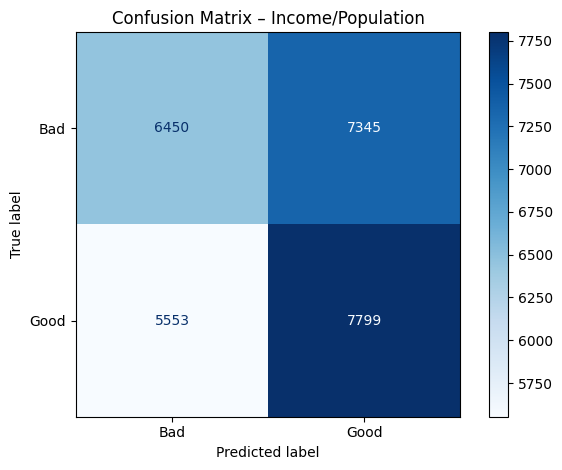

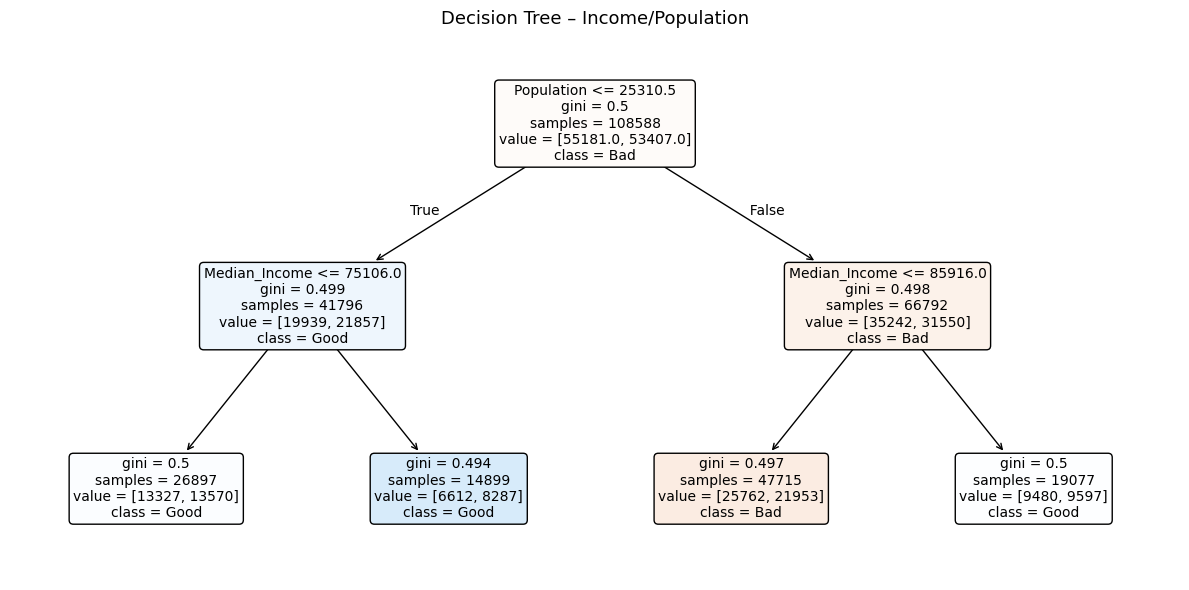


 Decision Tree (Ethnicity (Asian)) 


 Accuracy: 0.5149 (51.49%) 


 Confusion Matrix:
 [[12400  1395]
 [11773  1579]]


<Figure size 400x400 with 0 Axes>

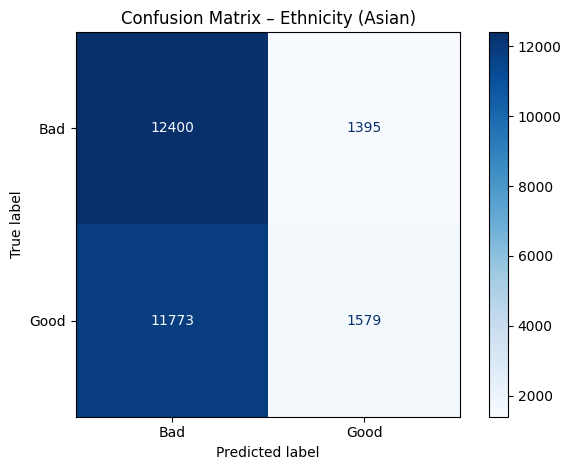

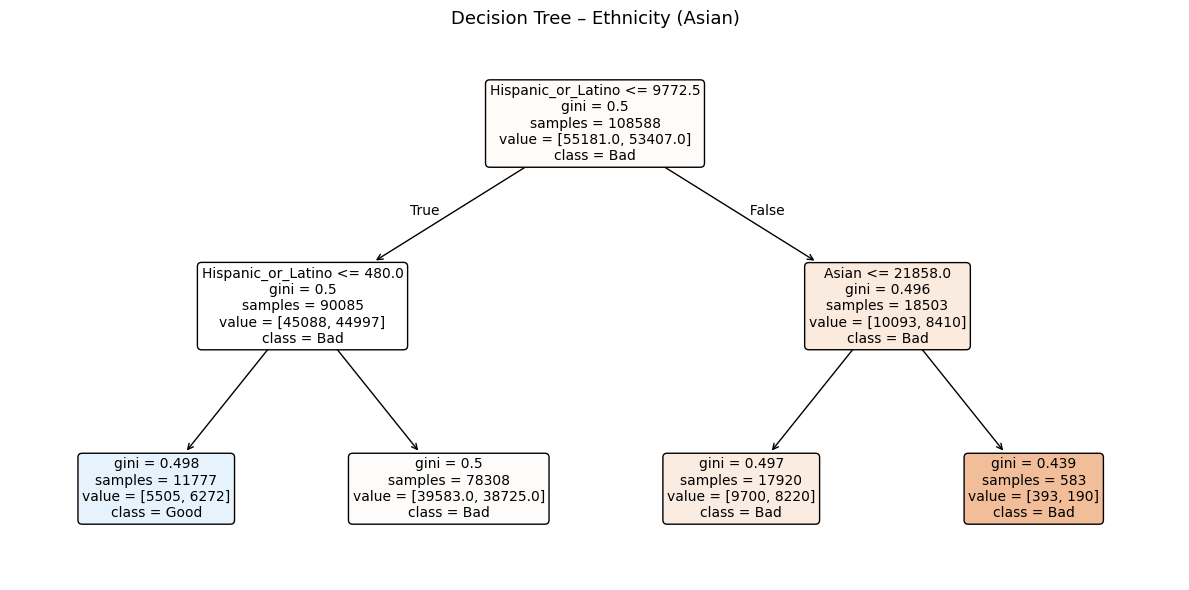


 Decision Tree (IsChain/Tag Count) 


 Accuracy: 0.6552 (65.52%) 


 Confusion Matrix:
 [[ 6917  6878]
 [ 2483 10869]]


<Figure size 400x400 with 0 Axes>

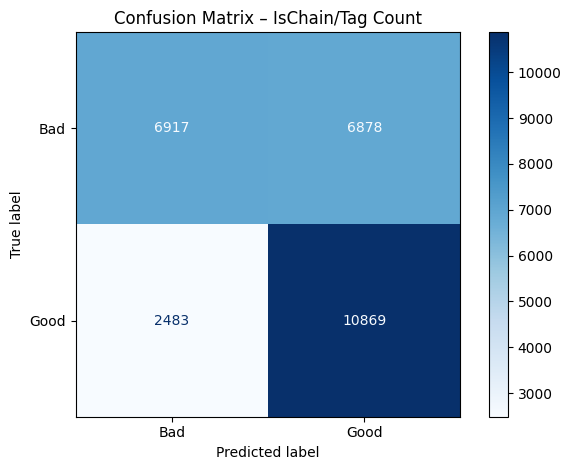

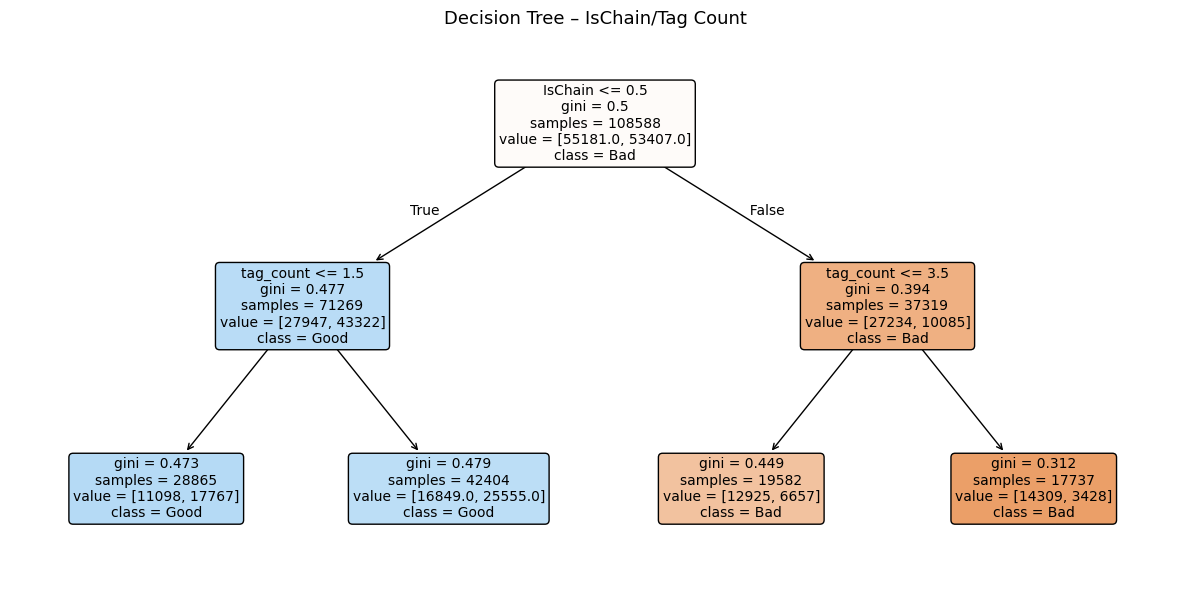

In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# 3 custom feature sets to guide root node
root_feature_sets = [
    ['Median_Income', 'Population'],               # Possibly root = Median_Income
    ['Asian', 'Hispanic_or_Latino'],               # Possibly root = Asian
    ['IsChain', 'tag_count'],                      # Possibly root = IsChain
]

root_titles = ['Income/Population', 'Ethnicity (Asian)', 'IsChain/Tag Count']
accuracies = []

# Loop through each tree setup
for i, features_subset in enumerate(root_feature_sets):
    model = DecisionTreeClassifier(max_depth=2, random_state=42)
    model.fit(X_train[features_subset], y_train)

    y_pred = model.predict(X_test[features_subset])
    y_prob = model.predict_proba(X_test[features_subset])[:, 1]
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    # Store accuracy for comparison plot
    accuracies.append(acc)

    print(f"\n Decision Tree ({root_titles[i]}) \n")
    print(f"\n Accuracy: {acc:.4f} ({round(acc*100, 2)}%) \n")
    print("\n Confusion Matrix:\n", cm)

    # Plot confusion matrix
    plt.figure(figsize=(4, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Bad", "Good"]).plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix – {root_titles[i]}")
    plt.grid(False)
    plt.tight_layout()
    plt.show()

    # Plot tree visualization
    plt.figure(figsize=(12, 6))
    plot_tree(model,
              feature_names=features_subset,
              class_names=["Bad", "Good"],
              filled=True,
              rounded=True,
              fontsize=10)
    plt.title(f"Decision Tree – {root_titles[i]}", fontsize=13)
    plt.tight_layout()
    plt.show()

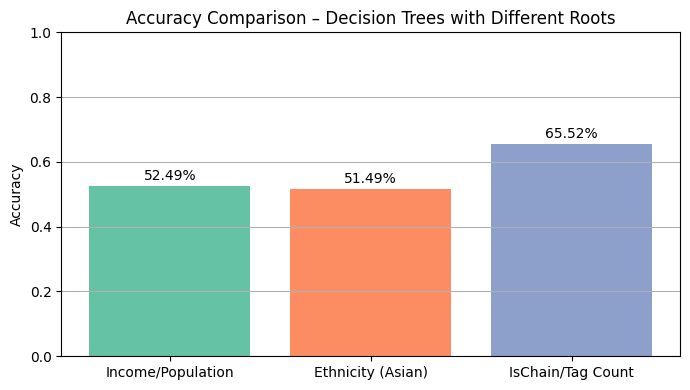

In [22]:
# Accuracy comparison chart
plt.figure(figsize=(7, 4))
plt.bar(root_titles, accuracies, color=["#66c2a5", "#fc8d62", "#8da0cb"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison – Decision Trees with Different Roots")
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f"{round(acc*100, 2)}%", ha='center', fontsize=10)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

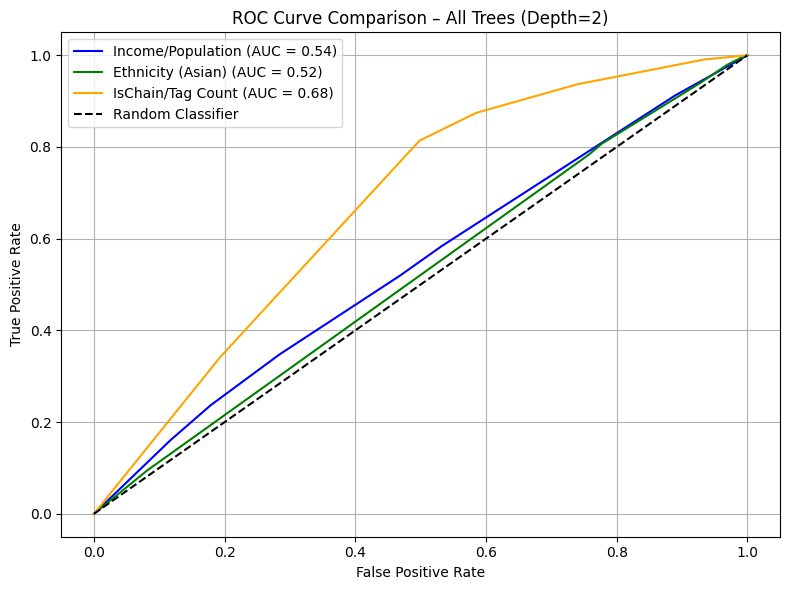

In [23]:
#Plot overall ROC curves for all models
plt.figure(figsize=(8, 6))

colors = ['blue', 'green', 'orange']
for i, features_subset in enumerate(root_feature_sets):
    model = DecisionTreeClassifier(max_depth=3, random_state=42)
    model.fit(X_train[features_subset], y_train)
    y_prob = model.predict_proba(X_test[features_subset])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)

    plt.plot(fpr, tpr, label=f"{root_titles[i]} (AUC = {auc:.2f})", color=colors[i])

# Plot baseline and finalize graph
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison – All Trees (Depth=2)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
